# Imports

In [39]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# Load cleaned data

In [2]:
df = pd.read_csv('data/clean_data_v1.csv')

In [3]:
df.head()

,Unnamed: 0,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


# Create Train/Val/Test splits

In [21]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [23]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model and Params Definition

In [31]:
models = {
     "LogisticRegression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000))
        ]),
        {
            "model__C": [0.1, 1, 10]
        }
    ),

     "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", svm.SVC())
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    ),

    "DecisionTree": (tree.DecisionTreeClassifier(), {"max_depth": [3, 5, 7]}),

    "RandomForest": (RandomForestClassifier(), {"n_estimators": [50, 100, 200]})
}

# Training Loop

In [35]:
results = {}
for name, (model, params) in models.items():
    grid_search = GridSearchCV(model, params, cv=skf, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    accuracy = best_model.score(X_val, y_val)
    results[name] = {
        "best_model": best_model,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'validation_accuracy': accuracy
    }

# Best Model's performance

In [37]:
for model_name, result in results.items():
    print(model_name)
    print(result["best_score"])
    print(result["best_params"])
    print(result["validation_accuracy"])
    print("-" * 30)

LogisticRegression
0.8054285714285714
{'model__C': 0.1}
0.8133333333333334
------------------------------
SVM
0.8531428571428572
{'model__C': 1, 'model__kernel': 'rbf'}
0.8593333333333333
------------------------------
DecisionTree
0.8508571428571429
{'max_depth': 5}
0.852
------------------------------
RandomForest
0.8595714285714285
{'n_estimators': 200}
0.8633333333333333
------------------------------


# Visualize Models Metrics


LogisticRegression
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1195
           1       0.70      0.17      0.27       305

    accuracy                           0.82      1500
   macro avg       0.76      0.57      0.58      1500
weighted avg       0.80      0.82      0.77      1500



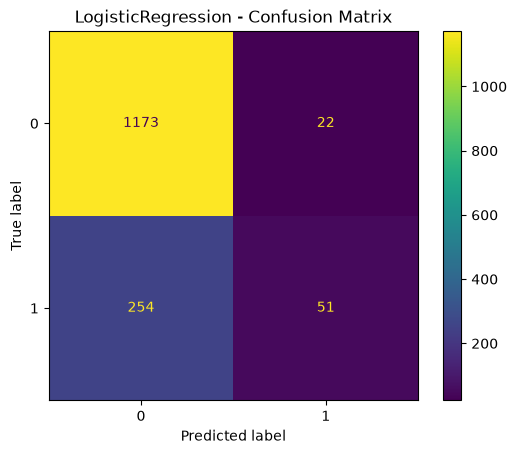

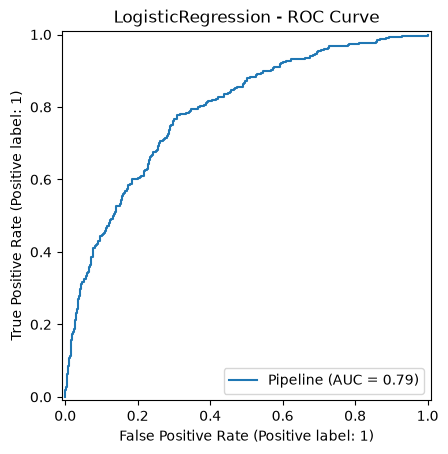

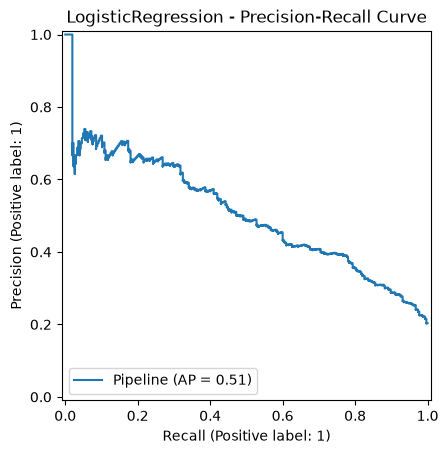


SVM
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1195
           1       0.85      0.38      0.52       305

    accuracy                           0.86      1500
   macro avg       0.85      0.68      0.72      1500
weighted avg       0.86      0.86      0.84      1500



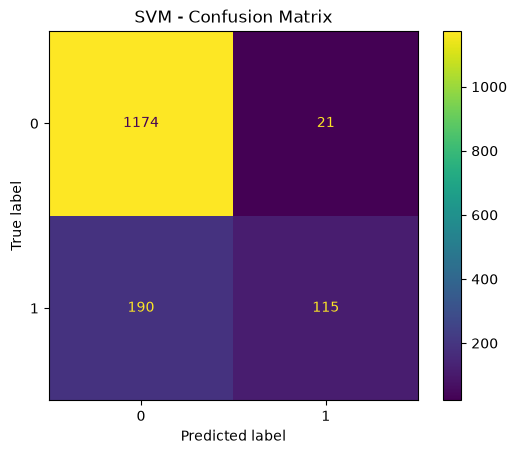

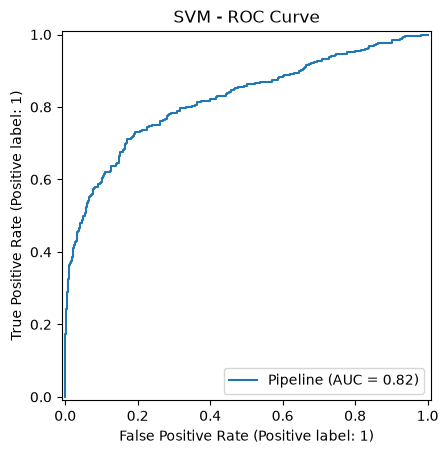

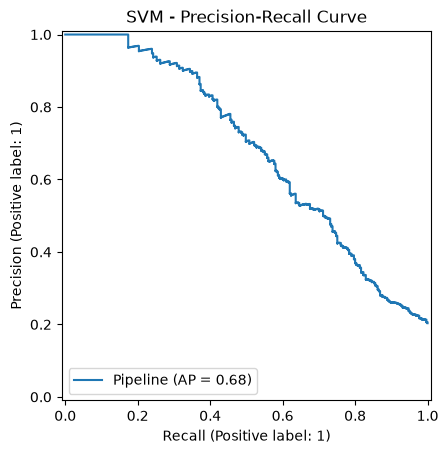


DecisionTree
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      1195
           1       0.88      0.40      0.55       305

    accuracy                           0.87      1500
   macro avg       0.87      0.69      0.74      1500
weighted avg       0.87      0.87      0.85      1500



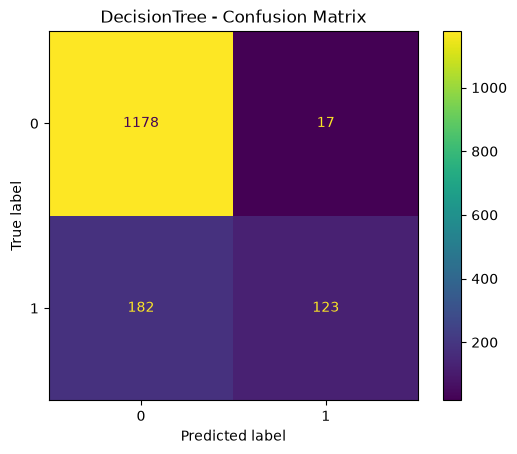

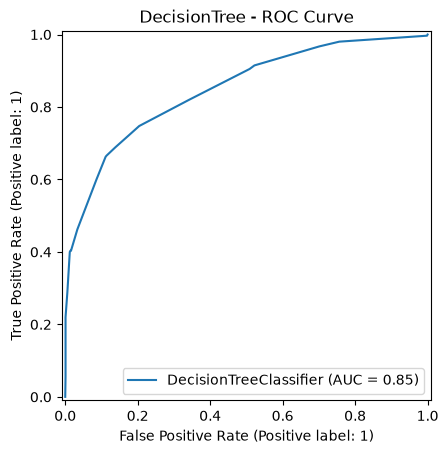

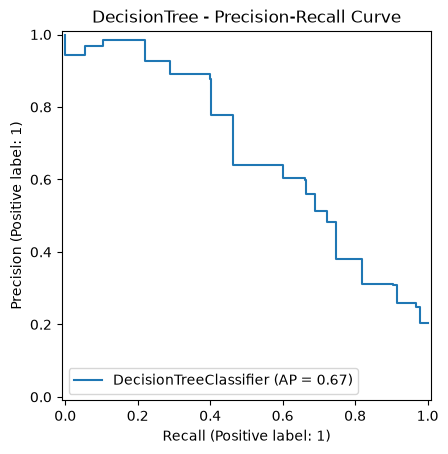


RandomForest
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1195
           1       0.78      0.47      0.58       305

    accuracy                           0.87      1500
   macro avg       0.83      0.72      0.75      1500
weighted avg       0.86      0.87      0.85      1500



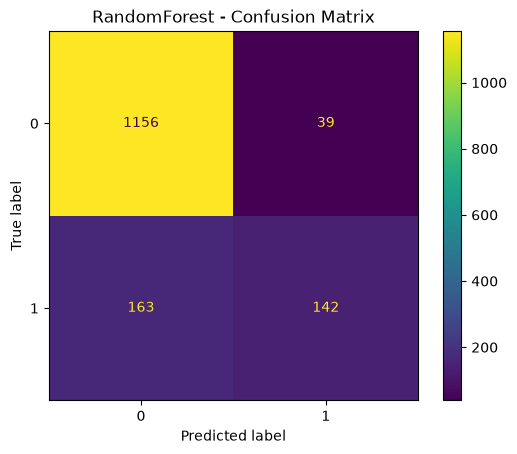

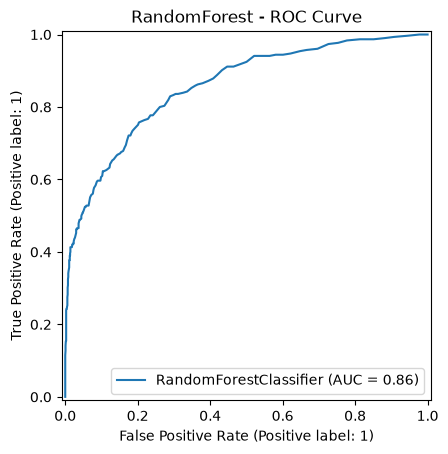

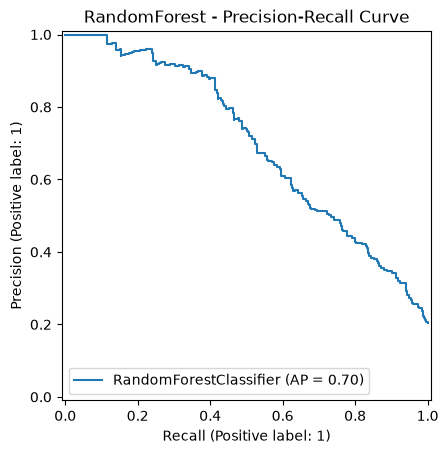

In [38]:
for name, result in results.items():
    model = result["best_model"]

    print(f"\n{name}")
    print(classification_report(y_test, model.predict(X_test)))

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} - ROC Curve")
    plt.show()

    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.show()